## Part 1:  How do we turn a sentence into a row of numbers?

In [61]:
import pandas as pd
import numpy as np
import torch
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

from torch import nn

In [62]:
data = pd.read_csv('data/train.csv')
data.head(10)
SEED = 42

In [63]:
data['sentence'] = data['sentence'].str.lower()
data['label'] = [1 if el == 'OBJ' else 0 for el in data['label']]
data.head(10)

,id,sentence,label
0,fde9e435-8186-4cb3-8ec1-1be67ddb5f96,"""трудно е класически оркестър и рок банда да с...",1
1,bb522430-40f0-4781-9910-92a1aefd013b,"следователно, москва е пазителка на православн...",1
2,d6a84f01-9153-4f3b-bca6-ed2b2edc6a9e,от washington post са изготвили подробен матер...,1
3,3623488a-c528-4509-a92d-9ad4b49099ec,и пак така относно заслугите за постигнатото о...,1
4,587b0e27-6ac8-433f-9b99-adf8d9c7c0a2,понякога удобството да разтвориш набързо стран...,1
5,f2d2aab0-25af-4bef-b678-badd5b390e8d,"вчера барак обама, отиващият си тъжен стопанин...",0
6,f94840f8-7fb6-42e3-aa84-0a250d58af5b,дали защото първият черен президент на сащ си ...,0
7,b30bd670-07fd-40ac-82d7-c67988f57cc3,"и като доказателство за това, гръмна и следващ...",0
8,512b57e5-9b65-43a8-8dec-01bef61a3ad6,"последният път, когато америка се обърна навът...",0
9,d6bad64f-59f2-491e-9d99-103d2748d647,"шок, бомба, ужас!",0


#### We want to test how an algorithm predicts subjectivity. How do we do that ?

In [64]:
vectorizer = TfidfVectorizer(max_features=4000)
X_train, X_test, y_train, y_test = train_test_split(data['sentence'], data['label'],test_size=0.2)

In [65]:
print(y_train)

756    1
21     0
521    0
638    1
460    1
      ..
642    1
271    0
405    1
721    1
668    1
Name: label, Length: 640, dtype: int64


In [6]:
print(y_train.values)

[0 0 1 0 0 1 1 1 1 1 1 0 1 1 1 1 1 0 1 0 0 1 1 0 0 0 1 1 0 1 0 1 1 0 0 0 1
 0 1 0 0 1 1 1 0 1 0 0 0 0 1 0 1 0 1 0 0 0 0 0 0 1 0 0 1 0 0 1 0 1 0 1 1 0
 1 0 1 0 0 1 0 1 1 1 1 0 0 0 1 0 1 0 1 1 0 0 0 0 1 0 0 1 0 0 0 0 1 1 1 0 0
 0 0 1 0 1 1 1 0 1 0 1 1 1 1 1 0 0 0 1 0 0 1 1 0 0 1 1 0 1 0 1 1 0 0 1 1 1
 1 1 0 1 1 0 1 0 1 1 1 1 0 1 0 1 1 0 1 0 1 1 0 1 0 0 0 1 1 1 1 0 0 0 0 1 0
 1 1 1 0 0 0 1 1 0 1 0 1 1 0 1 0 1 0 0 0 0 0 0 1 0 1 1 0 1 1 0 1 0 1 0 0 0
 1 0 0 0 1 0 1 1 0 1 0 1 1 1 1 0 1 0 0 1 0 1 0 1 1 0 1 1 0 1 1 1 1 0 1 1 0
 1 0 0 0 1 1 1 1 1 0 0 1 0 1 0 0 0 1 1 0 1 0 1 0 1 0 0 1 0 1 1 0 1 1 0 1 1
 1 0 0 1 1 0 1 1 0 0 1 0 1 0 1 1 1 0 0 0 1 0 1 0 0 1 1 0 1 1 1 1 1 1 0 1 1
 1 1 0 1 1 0 1 1 0 1 1 0 1 1 0 1 1 0 0 1 0 0 1 0 1 1 1 1 1 1 1 0 0 0 1 0 1
 1 0 1 1 0 1 1 0 0 0 1 0 1 0 1 0 1 1 1 0 0 0 1 1 1 1 1 0 0 1 1 1 1 0 0 1 1
 1 1 0 0 0 1 0 0 1 0 1 1 1 1 1 0 1 0 0 0 1 0 1 1 1 0 1 1 1 0 1 0 0 1 1 1 1
 1 1 1 0 1 1 1 1 1 1 0 0 1 1 0 1 1 0 1 0 0 0 1 0 1 0 0 1 0 1 1 0 0 1 0 1 1
 0 0 1 0 1 1 0 1 1 1 1 0 

In [66]:
print(y_train.values.reshape(-1,1).astype(np.float32))

[[1.]
 [0.]
 [0.]
 [1.]
 [1.]
 [0.]
 [0.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [0.]
 [1.]
 [0.]
 [1.]
 [0.]
 [0.]
 [0.]
 [0.]
 [1.]
 [0.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [0.]
 [0.]
 [0.]
 [0.]
 [1.]
 [1.]
 [0.]
 [0.]
 [0.]
 [0.]
 [1.]
 [0.]
 [0.]
 [0.]
 [0.]
 [1.]
 [0.]
 [0.]
 [0.]
 [1.]
 [0.]
 [0.]
 [1.]
 [0.]
 [1.]
 [1.]
 [1.]
 [0.]
 [1.]
 [1.]
 [1.]
 [0.]
 [1.]
 [1.]
 [0.]
 [0.]
 [0.]
 [1.]
 [1.]
 [1.]
 [0.]
 [0.]
 [1.]
 [0.]
 [1.]
 [1.]
 [0.]
 [1.]
 [0.]
 [1.]
 [0.]
 [1.]
 [1.]
 [1.]
 [0.]
 [1.]
 [0.]
 [1.]
 [1.]
 [0.]
 [1.]
 [0.]
 [0.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [0.]
 [0.]
 [1.]
 [0.]
 [1.]
 [0.]
 [0.]
 [0.]
 [1.]
 [1.]
 [1.]
 [0.]
 [0.]
 [1.]
 [0.]
 [0.]
 [1.]
 [0.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [0.]
 [1.]
 [1.]
 [1.]
 [1.]
 [0.]
 [1.]
 [0.]
 [0.]
 [1.]
 [1.]
 [0.]
 [0.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [0.]
 [1.]
 [0.]
 [1.]
 [0.]
 [0.]
 [1.]
 [1.]
 [1.]
 [1.]
 [0.]
 [0.]
 [1.]
 [0.]
 [1.]
 [0.]
 [0.]
 [0.]
 [1.]
 [0.]
 [1.]
 [0.]
 [0.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.

In [67]:
X_train_tfidf = vectorizer.fit_transform(X_train).toarray().astype(np.float32)
X_test_tfidf  = vectorizer.transform(X_test).toarray().astype(np.float32)
y_train_np = y_train.values.reshape(-1,1).astype(np.float32)
y_test_np  = y_test.values.reshape(-1,1).astype(np.float32)

In [68]:
X_train_tfidf.shape

(640, 4000)

In [10]:
type(y_train_np)

numpy.ndarray

In [11]:
class SubjectivityDataset(Dataset):
  def __init__(self, X, y):
    self.X = X
    self.y = y
  def __len__(self):
    return len(self.X)

  def __getitem__(self,idx):
    return self.X[idx], self.y[idx]

In [69]:
train_dataset = SubjectivityDataset(X_train_tfidf, y_train_np)
test_dataset  = SubjectivityDataset(X_test_tfidf,  y_test_np)

In [ ]:
class LinearClassifier(nn.Module):
  def __init__(self, features_size, num_classes):
    super(LinearClassifier, self).__init__()
    self.linear  = nn.Linear(features_size, num_classes)
    
  def forward(self, x):
    return self.sigmoid(self.linear(x))

In [ ]:
model = LinearClassifier(512, 1)

In [72]:
sgd = torch.optim.SGD(model.parameters(), lr=0.001)
bce = nn.BCELoss()  # -> Why this loss function?

In [73]:
EPOCHS     = 5
BATCH_SIZE = 16

def train(model, optimizer, loss_fn, dataset):
  model.train()
  for epoch in range(EPOCHS + 1):
    cost = []
    dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

    for X, y in tqdm(dataloader):
      optimizer.zero_grad()
      preds = model(X)
      loss  = loss_fn(preds, y)
      loss.backward()
      optimizer.step()
      cost.append(loss.detach().cpu().item())
    print("Epoch: {:04d} cost={:.9f}".format(epoch, np.mean(cost)))

def evaluate(model, dataset):
  model.eval()
  correct = total = 0
  with torch.no_grad():
    for X, y in DataLoader(dataset, batch_size=64):
      preds   = (model(X) > 0.5).float()
      correct += (preds == y).sum().item()
      total   += len(y)
  print(f"Accuracy: {correct/total:.4f}")

In [75]:
train(model, sgd, bce, train_dataset)
evaluate(model, test_dataset)

100%|██████████| 40/40 [00:00<00:00, 1222.24it/s]


Epoch: 0000 cost=0.692051224


100%|██████████| 40/40 [00:00<00:00, 1480.71it/s]


Epoch: 0001 cost=0.691973956


100%|██████████| 40/40 [00:00<00:00, 1428.07it/s]


...

Epoch: 0003 cost=0.691822289


100%|██████████| 40/40 [00:00<00:00, 1382.91it/s]


Epoch: 0004 cost=0.691749290


100%|██████████| 40/40 [00:00<00:00, 1364.63it/s]

Epoch: 0005 cost=0.691676988
Accuracy: 0.5776


## Is this accuracy considered good ? How would we know ?

---

In [76]:
y_train_np.mean()

np.float32(0.5421875)

In [78]:
majority_class = round(y_train_np.mean())           # 0 or 1, whichever is more common
baseline_acc   = (y_test_np == majority_class).mean()
print(f"Majority class: {majority_class}  →  Baseline accuracy: {baseline_acc:.4f}")

Majority class: 1  →  Baseline accuracy: 0.5776


## This would be the minimum effort to quickly run and see results for our task. But is it enough ?
### We want to go beyond running a single algorithm and getting results, we want to see how we can improve the performance on our task without changing to another architecture

---
# Part 2: Feature Engineering

So far we let TF-IDF decide what "features" a sentence has. But we know things about language that a simple bag-of-words misses. Feature engineering is the process of encoding that knowledge manually — turning human intuitions into numbers the model can use.

There are two strategies:
- **Manual** — you design features by hand based on domain knowledge.
- **Automatic** — you let a statistical method measure which features are most informative, then keep only those.

## 2a. Manual Feature Engineering

Subjective sentences often *feel* different from objective ones. Think about:
- They tend to use more **exclamation marks and question marks** (emotional punctuation).
- They tend to be **shorter** — a quick opinion vs. a factual report.

These are our two hand-crafted features.

In [79]:
import re

def manual_features(sentences):
    """Returns a (N, 2) array with:
       col 0 - number of exclamation/question marks
       col 1 - sentence length in tokens
    """
    feats = []
    for s in sentences:
        punct_count = len(re.findall(r'[!?]', s))
        word_count  = len(s.split())
        feats.append([punct_count, word_count])
    return np.array(feats, dtype=np.float32)

X_train_manual = manual_features(X_train)
X_test_manual  = manual_features(X_test)
print("Manual feature matrix shape:", X_train_manual.shape)
print("Sample rows:\n", X_train_manual[:10])

Manual feature matrix shape: (640, 2)
Sample rows:
 [[ 0. 15.]
 [ 0. 32.]
 [ 0. 20.]
 [ 0. 19.]
 [ 0. 11.]
 [ 0. 17.]
 [ 0. 28.]
 [ 2. 33.]
 [ 0.  5.]
 [ 0. 20.]]


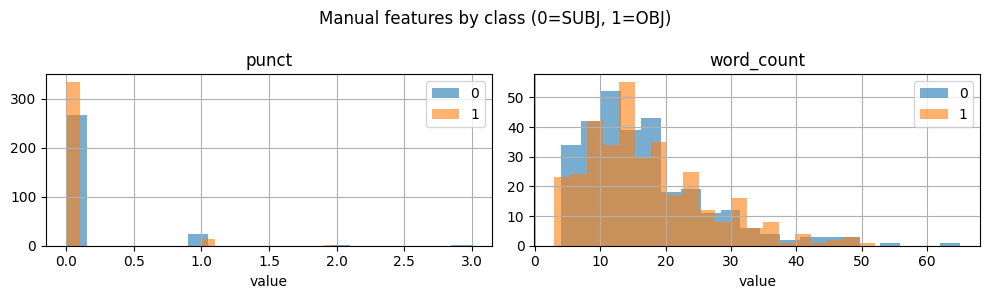

In [80]:
# Quick sanity check: do these features differ between classes?
import matplotlib.pyplot as plt


df_feat = pd.DataFrame(X_train_manual, columns=['punct', 'word_count'])
df_feat['label'] = y_train.values

fig, axes = plt.subplots(1, 2, figsize=(10, 3))
for ax, col in zip(axes, ['punct', 'word_count']):
    df_feat.groupby('label')[col].hist(ax=ax, alpha=0.6, bins=20, legend=True)
    ax.set_title(col)
    ax.set_xlabel('value')
plt.suptitle('Manual features by class (0=SUBJ, 1=OBJ)')
plt.tight_layout()
plt.show()

In [82]:
# Train the same linear model using ONLY the 2 manual features
train_manual = SubjectivityDataset(X_train_manual, y_train_np)
test_manual  = SubjectivityDataset(X_test_manual,  y_test_np)

model_manual = LinearClassifier(2, 1)
train(model_manual, torch.optim.SGD(model_manual.parameters(), lr=0.01), bce, train_manual)
evaluate(model_manual, test_manual)

100%|██████████| 40/40 [00:00<00:00, 2892.72it/s]


Epoch: 0000 cost=0.747027420


100%|██████████| 40/40 [00:00<00:00, 6480.94it/s]


Epoch: 0001 cost=0.696908444


100%|██████████| 40/40 [00:00<00:00, 3216.00it/s]


...

Epoch: 0003 cost=0.712444629


100%|██████████| 40/40 [00:00<00:00, 2399.01it/s]


Epoch: 0004 cost=0.730389152


100%|██████████| 40/40 [00:00<00:00, 3500.58it/s]

Epoch: 0005 cost=0.733294153
Accuracy: 0.5839


> **Discussion:** The accuracy here is likely higher than TF-IDF — we've thrown away most of the vocabulary signal. But notice that *2 numbers* got us somewhere reasonable. This illustrates that good feature engineering can matter a lot, especially when you don't have much data.

We can also **combine** our manual features with TF-IDF to potentially get the best of both worlds:

In [85]:
# Concatenate TF-IDF + manual features
X_train_combined = np.hstack([X_train_tfidf, X_train_manual])
X_test_combined  = np.hstack([X_test_tfidf,  X_test_manual])
print("Combined shape:", X_train_combined.shape)  # 640 x 4002

train_combined = SubjectivityDataset(X_train_combined, y_train_np)
test_combined  = SubjectivityDataset(X_test_combined,  y_test_np)

model_combined = LinearClassifier(X_train_combined.shape[1], 1)
train(model_combined, torch.optim.SGD(model_combined.parameters(), lr=0.001), bce, train_combined)
evaluate(model_combined, test_combined)

Combined shape: (640, 4002)


100%|██████████| 40/40 [00:00<00:00, 1204.74it/s]


Epoch: 0000 cost=0.692462295


100%|██████████| 40/40 [00:00<00:00, 1288.99it/s]


Epoch: 0001 cost=0.692832617


...

Epoch: 0003 cost=0.691529541


100%|██████████| 40/40 [00:00<00:00, 1532.52it/s]


Epoch: 0004 cost=0.694652130


100%|██████████| 40/40 [00:00<00:00, 1547.73it/s]

Epoch: 0005 cost=0.692137045
Accuracy: 0.5776


---
## 2b. Automatic Feature Selection

TF-IDF gives us 4000 features, but most tokens are probably noise. **Feature selection** asks: which of these 4000 features actually carry signal for our classification task?

We'll rank every token by four metrics, then compare a model trained on **all** features vs. one trained on only the **top-K** most informative ones.

### Token Importance Metrics

1. Inverse Document Frequency (IDF) 

    * IDF measures how informative a token is based on how rare it is across the entire corpus.

2. Chi-Squared 

    * ($\chi^2$)This metric tests the statistical independence between a token $t$ and a class $c$. It answers: Is the presence of this word significantly related to the target class, or is it just a coincidence?
    $$\chi^2_{avg}(t) = \sum{P(c_i) \cdot \chi^2(c_i, t)}$$

3. Information Gain (IG) 
    * Information Gain measures the reduction in entropy (uncertainty). It tells us how much knowing the presence or absence of a token helps us predict the class.
$$G(t) = -\sum{P(c_i) \log{P(c_i)}} + P(t)\sum{P(c_i|t) \log{P(c_i|t)}} + P(\neg{t})\sum{P(c_i|\neg{t}) \log{P(c_i|\neg{t})}}$$

4. Mutual Information (MI)
    * Mutual Information quantifies the amount of information (in bits) obtained about one random variable (the class) through observing another (the token).
    $$MI(t,c) = \log{\frac{P(t,c)}{P(t)P(c)}} = \log{P(t|c)} - \log{P(t)}$$

| Metric | What it measures |
|---|---|
| **IDF** | How rare a token is across all documents — rare tokens are more specific |
| **Chi²** | Statistical dependence between a token and the class label |
| **Information Gain** | How much the presence/absence of a token reduces class uncertainty |
| **Mutual Information** | How many "bits" a token tells us about the class |




In [86]:
# We compute all four metrics in one pass over the vocabulary.
# Inputs: the fitted vectorizer, the binary presence matrix, and the labels.

vocab    = np.array(vectorizer.get_feature_names_out())   # (V,)
idf_vals = vectorizer.idf_                                 # (V,) — free from the vectorizer
X_bin    = (X_train_tfidf > 0).astype(float)              # binary presence: (N, V)
y_flat   = y_train_np.ravel()                              # (N,)

classes, counts = np.unique(y_flat, return_counts=True)
N   = len(y_flat)
P_c = counts / N
H_C = -np.sum(P_c * np.log2(P_c + 1e-12))                 

chi2_scores = np.zeros(len(vocab))
ig_scores   = np.zeros(len(vocab))
mi_scores   = np.zeros(len(vocab))

for j in range(len(vocab)):
    t  = X_bin[:, j]
    nt = 1 - t
    P_t  = t.mean()
    P_nt = 1 - P_t

    chi2_t = ig_t = mi_t = 0.0
    for c, p_ci in zip(classes, P_c):
        in_c = (y_flat == c).astype(float)
        A = (t  * in_c     ).sum()   # present  & in class
        B = (t  * (1-in_c) ).sum()   # present  & not in class
        C = (nt * in_c     ).sum()   # absent   & in class
        D = (nt * (1-in_c) ).sum()   # absent   & not in class

        for O, E_num, E_den in [(A,(A+B)*(A+C),N),(B,(A+B)*(B+D),N),
                                (C,(C+D)*(A+C),N),(D,(C+D)*(B+D),N)]:
            E = E_num / (E_den + 1e-12)
            chi2_t += p_ci * (O - E)**2 / (E + 1e-12)

        P_ci_t  = A / (A + B + 1e-12)
        P_ci_nt = C / (C + D + 1e-12)
        ig_t += (P_t  * P_ci_t  * np.log2(P_ci_t  + 1e-12) +
                 P_nt * P_ci_nt * np.log2(P_ci_nt + 1e-12))

        mi_t += p_ci * np.log2((A/N) / (P_t * p_ci + 1e-12) + 1e-12)

    chi2_scores[j] = chi2_t
    ig_scores[j]   = H_C + ig_t
    mi_scores[j]   = mi_t

df_importance = pd.DataFrame(
    {'IDF': idf_vals, 'Chi2': chi2_scores, 'InfoGain': ig_scores, 'MutualInfo': mi_scores},
    index=vocab
)
df_importance.sort_values('Chi2', ascending=False).head(15)

,IDF,Chi2,InfoGain,MutualInfo
не,2.675538,36.240989,0.041393,-0.192443
да,2.092391,14.998113,0.016901,-0.033616
може,4.130825,14.473987,0.017172,-0.459525
според,4.629816,10.331403,0.014318,-0.886874
той,3.879511,9.914332,0.012095,-0.242695
но,3.634388,8.505986,0.009642,-0.132291
трябва,4.371987,8.088765,0.009395,-0.307289
ако,4.204933,7.204962,0.008263,-0.217841
добре,5.160444,6.833834,0.008501,-0.801629
мляко,5.671270,5.968128,0.008859,-21.097262


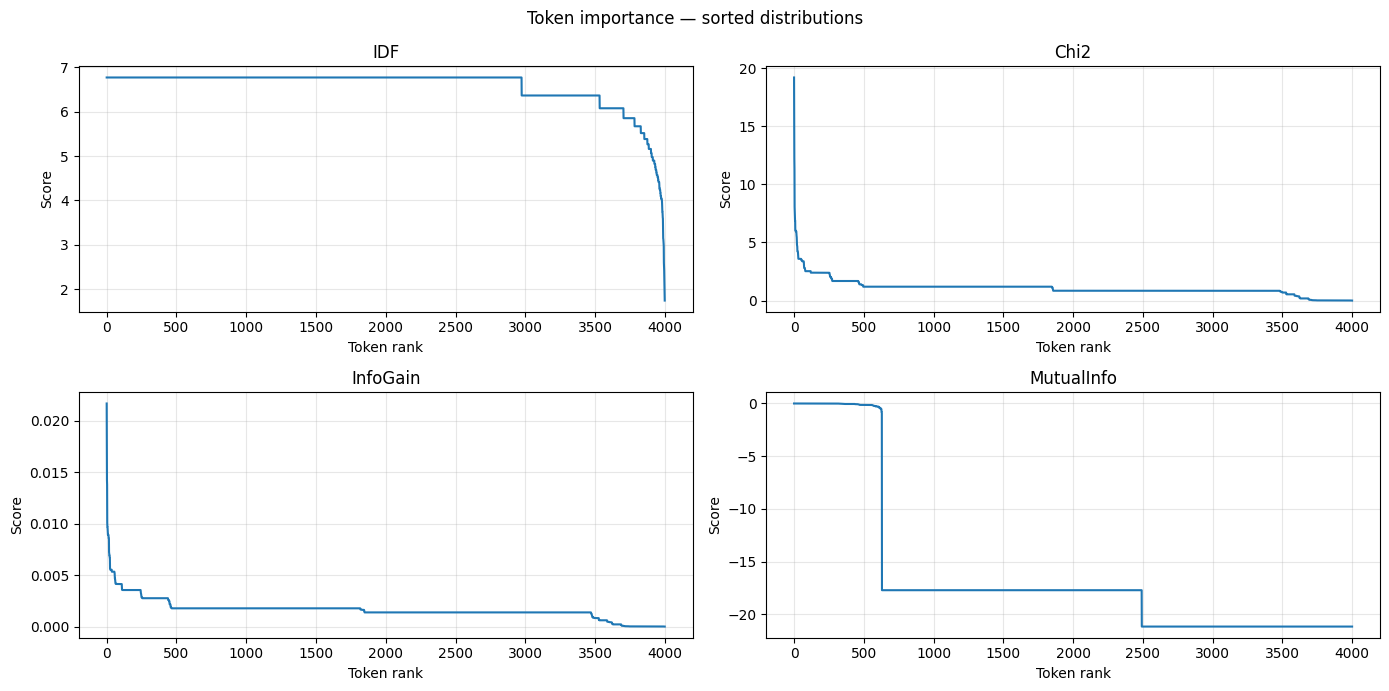

In [30]:
# Visualise the sorted distributions — look for the "elbow" to choose your cutoff K
fig, axes = plt.subplots(2, 2, figsize=(14, 7))
for ax, col in zip(axes.flat, ['IDF', 'Chi2', 'InfoGain', 'MutualInfo']):
    ax.plot(df_importance[col].sort_values(ascending=False).values)
    ax.set_title(col)
    ax.set_xlabel('Token rank')
    ax.set_ylabel('Score')
    ax.grid(True, alpha=0.3)
plt.suptitle('Token importance — sorted distributions')
plt.tight_layout()
plt.show()

In [ ]:
# Select the top-K tokens by Chi2 and retrain — does fewer features hurt?
K = 500
top_k_idx = df_importance['Chi2'].nlargest(K).index   # token strings
# Map back to column indices in X_train_tfidf
vocab_list  = list(vocab)
top_k_cols  = [vocab_list.index(t) for t in top_k_idx]

X_train_sel = X_train_tfidf[:, top_k_cols]
X_test_sel  = X_test_tfidf[:,  top_k_cols]
print(f"Reduced feature matrix: {X_train_sel.shape}  (was {X_train_tfidf.shape})")

train_sel = SubjectivityDataset(X_train_sel, y_train_np)
test_sel  = SubjectivityDataset(X_test_sel,  y_test_np)

model_sel = LinearClassifier(K, 1)
train(model_sel, torch.optim.SGD(model_sel.parameters(), lr=0.001), bce, train_sel)
evaluate(model_sel, test_sel)

Avg 3, 5

Reduced feature matrix: (640, 1500)  (was (640, 4000))


100%|██████████| 40/40 [00:00<00:00, 2678.95it/s]


Epoch: 0000 cost=0.692565970


100%|██████████| 40/40 [00:00<00:00, 2113.37it/s]


Epoch: 0001 cost=0.692502823


...

Epoch: 0003 cost=0.692368951


100%|██████████| 40/40 [00:00<00:00, 2130.87it/s]


Epoch: 0004 cost=0.692303781


100%|██████████| 40/40 [00:00<00:00, 2630.07it/s]

Epoch: 0005 cost=0.692241092
Accuracy: 0.5714


> **Discussion:** With only ~12% of the original features we often get *comparable or better* accuracy. Fewer features means:
> - Faster training
> - Less overfitting
> - A model whose weights are easier to interpret
>
> Try changing `K` and watch what happens. There's usually a sweet-spot around the elbow of the Chi² curve.

| Model | Accuracy | Δ vs Baseline |
|---|---|---|
| Baseline (Random) | 0.4996 | — |
| Baseline (Majority) | 0.5776 | — |
| Log Reg TF-IDF| 0.5776| |
| Log Reg Manual | 0.5776 | |
| Log Reg Auto 500 | 0.4223 | |
| Log Reg Auto 1500 | 0.5714 | |